# 01 - Baseline: noisy qubits, syndromes and MWPM

**In plain words.** We store one bit of quantum information in `d` qubits (a *repetition code*). Noise flips some of them. Parity checks (*syndromes*) tell us *where neighbours disagree* without reading the data. A *decoder* looks at the lit-up checks and guesses whether the stored bit was flipped. MWPM (minimum-weight perfect matching) is the classic decoder: it explains the lit checks with the fewest, most likely errors.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))
QUICK = True   # False = bigger budgets (slower, tighter error bars)
import numpy as np
from src.noise import NoiseSpec
from src.circuits import build_repetition_circuit
from src.data import sample_syndromes
from src.decoders import MWPMDecoder
from src.evaluate import wilson_interval, majority_vote_failure, code_capacity_flip_prob, fit_loglog_slope

## 1. Sanity check against an exact formula
With no repeated measurement (`rounds=0`) the best decoder is a majority vote, so MWPM must match the binomial formula. If it does not, there is a bug.

In [2]:
shots = 100_000 if QUICK else 1_000_000
for d in (3, 5, 7):
    c = build_repetition_circuit(d, 0, NoiseSpec.uniform(0.1))
    det, obs = sample_syndromes(c, shots, seed=1)
    ler = MWPMDecoder.from_circuit(c).logical_error_rate(det, obs)
    print(f"d={d}: MWPM {ler:.5f}   exact {majority_vote_failure(d, code_capacity_flip_prob(0.1)):.5f}")

d=3: MWPM 0.06391   exact 0.06332
d=5: MWPM 0.02912   exact 0.02827
d=7: MWPM 0.01296   exact 0.01310


## 2. Does a bigger code help? (E1)
Below a threshold error rate, larger `d` should give a *lower* logical error rate, scaling like `p^((d+1)/2)`.

3 ['0.00179', '0.00695', '0.02618', '0.12422'] slope 1.94 expected 2.0


5 ['0.00019', '0.00153', '0.01116', '0.11827'] slope 2.94 expected 3.0


7 ['0.00000', '0.00025', '0.00491', '0.10917'] slope 4.3 expected 4.0


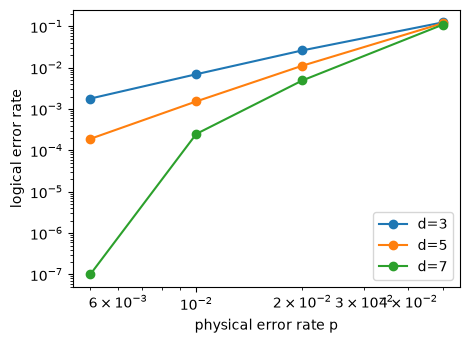

In [3]:
import matplotlib.pyplot as plt
ps = [0.005, 0.01, 0.02, 0.05]
fig, ax = plt.subplots(figsize=(5, 3.6))
for d in (3, 5, 7):
    lers = []
    for p in ps:
        c = build_repetition_circuit(d, d, NoiseSpec.uniform(p))
        det, obs = sample_syndromes(c, shots, seed=2)
        lers.append(MWPMDecoder.from_circuit(c).logical_error_rate(det, obs))
    ax.loglog(ps, np.maximum(lers, 1e-7), "o-", label=f"d={d}")
    print(d, [f"{x:.5f}" for x in lers], "slope", round(fit_loglog_slope(ps[:3], lers[:3]), 2), "expected", (d + 1) / 2)
ax.set_xlabel("physical error rate p"); ax.set_ylabel("logical error rate"); ax.legend(); plt.show()